<a href="https://colab.research.google.com/github/evienmejia816-droid/Ciencia-De-Datos/blob/main/Copia_de_Regresion_Logistica_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Regresión Logística: Clasificando Flores Iris

## Un Enfoque Práctico y Sencillo

---

### 🎯 **Objetivo de Esta Clase**

Dados **4 medidas simples** de una flor:
- 📏 Largo del sépalo
- 📏 Ancho del sépalo
- 🌼 Largo del pétalo
- 🌼 Ancho del pétalo

**Predecir: ¿Qué especie de flor es?**
- 🌸 Setosa
- 🌺 Versicolor
- 💜 Virginica

---

### 📊 **El Dataset Iris**

- **150 flores** en total
- **50 flores** de cada especie
- **4 características** (features)
- **3 clases** (especies)
- El dataset más famoso en Machine Learning

---

# PASO 1: Importar y Cargar Datos

Importamos las herramientas necesarias y cargamos el dataset.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configurar visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
np.random.seed(42)

print("✅ Librerías importadas")

✅ Librerías importadas


In [2]:
# Cargar el dataset
iris = load_iris()
X = iris.data  # 150 flores × 4 características
y = iris.target  # 150 etiquetas (0, 1, 2)

# Crear DataFrame para explorar más fácil
df = pd.DataFrame(X, columns=iris.feature_names)
df['Especie'] = iris.target_names[y]

print("📊 DATASET IRIS CARGADO")
print(f"\n  • Número de flores: {len(df)}")
print(f"  • Características: {len(iris.feature_names)}")
print(f"  • Especies: {len(iris.target_names)}\n")

# Mostrar primeras filas
print(df.head(10))

📊 DATASET IRIS CARGADO

  • Número de flores: 150
  • Características: 4
  • Especies: 3

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  Especie  
0  setosa  
1  setosa  
2  s

---

# PASO 2: Explorar los Datos

Veamos qué características tienen estas flores.

In [3]:
# Resumen estadístico
print("📈 ESTADÍSTICAS POR ESPECIE\n")
print(df.groupby('Especie').describe().round(2))

print("\n🌸 Cantidad de flores por especie:")
print(df['Especie'].value_counts().sort_index())

📈 ESTADÍSTICAS POR ESPECIE

           sepal length (cm)                                        \
                       count  mean   std  min   25%  50%  75%  max   
Especie                                                              
setosa                  50.0  5.01  0.35  4.3  4.80  5.0  5.2  5.8   
versicolor              50.0  5.94  0.52  4.9  5.60  5.9  6.3  7.0   
virginica               50.0  6.59  0.64  4.9  6.22  6.5  6.9  7.9   

           sepal width (cm)        ... petal length (cm)       \
                      count  mean  ...               75%  max   
Especie                            ...                          
setosa                 50.0  3.43  ...              1.58  1.9   
versicolor             50.0  2.77  ...              4.60  5.1   
virginica              50.0  2.97  ...              5.88  6.9   

           petal width (cm)                                       
                      count  mean   std  min  25%  50%  75%  max  
Especie                   

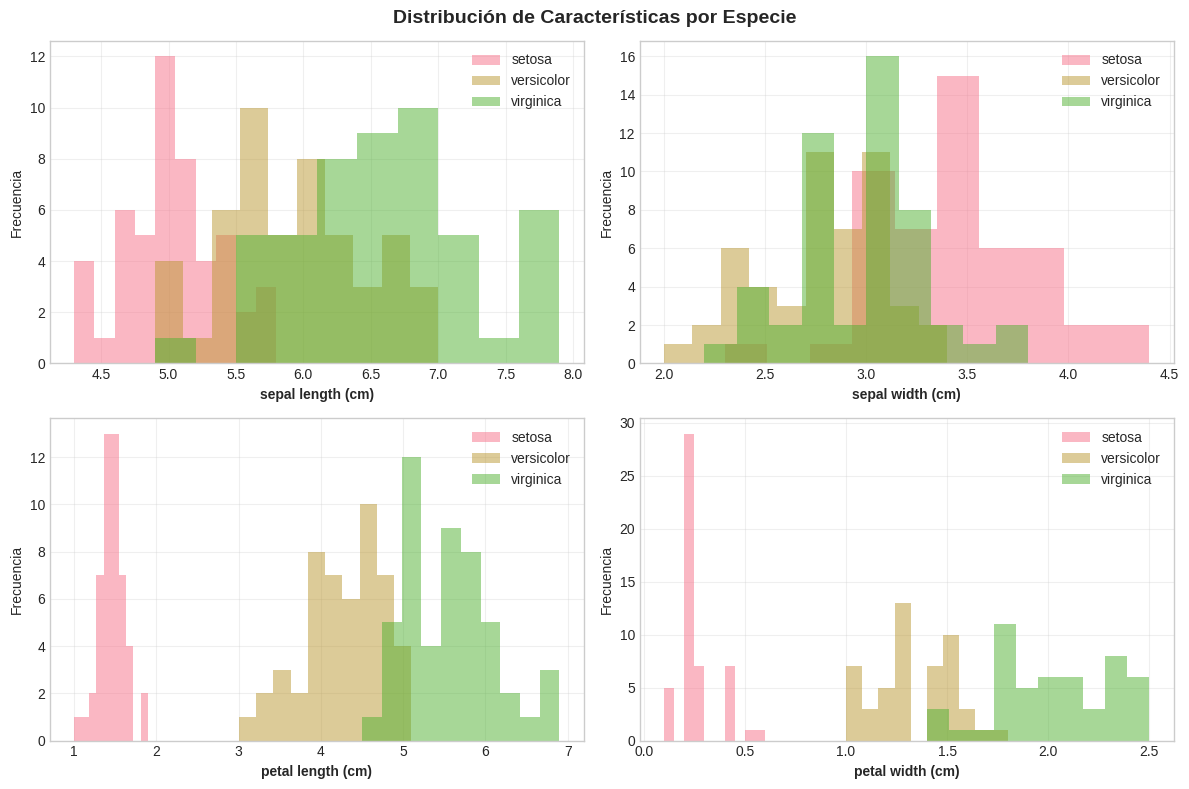

💡 Observación: Las especies tienen rangos diferentes de características.
   El modelo debe aprender estas diferencias.


In [4]:
# Visualizar distribución de características
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, caracteristica in enumerate(iris.feature_names):
    ax = axes[idx]

    for i, especie in enumerate(iris.target_names):
        datos = df[df['Especie'] == especie][caracteristica]
        ax.hist(datos, alpha=0.5, label=especie, bins=10)

    ax.set_xlabel(caracteristica, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de Características por Especie', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Observación: Las especies tienen rangos diferentes de características.")
print("   El modelo debe aprender estas diferencias.")

---

# PASO 3: Preparar los Datos

Dividimos en entrenamiento y prueba, luego normalizamos.

In [5]:
# Separar en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✂️  DIVISIÓN TRAIN/TEST")
print(f"  • Train: {len(X_train)} flores")
print(f"  • Test: {len(X_test)} flores")

# Normalizar (escalar características)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Datos normalizados y listos")

✂️  DIVISIÓN TRAIN/TEST
  • Train: 120 flores
  • Test: 30 flores

✅ Datos normalizados y listos


---

# PASO 4: Entrenar el Modelo

Creamos y entrenamos la Regresión Logística con 3 clases (multiclase).

In [6]:
# Crear y entrenar el modelo
modelo = LogisticRegression(
    max_iter=200,
    random_state=42,
    multi_class='multinomial' #!Importante - Clave para entender el comportamiento del Modelo¡
)

print("🤖 Entrenando el modelo...")
modelo.fit(X_train_scaled, y_train)
print("✅ ¡Modelo entrenado!")

# Información del modelo
print(f"\n📊 PARÁMETROS DEL MODELO:")
print(f"  • Interceptos: {modelo.intercept_.round(2)}")
print(f"  • Número de clases: {len(modelo.classes_)}")
print(f"  • Clases: {iris.target_names}")

🤖 Entrenando el modelo...
✅ ¡Modelo entrenado!

📊 PARÁMETROS DEL MODELO:
  • Interceptos: [-0.31  1.91 -1.6 ]
  • Número de clases: 3
  • Clases: ['setosa' 'versicolor' 'virginica']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


---

# PASO 5: Hacer Predicciones

Usamos el modelo para predecir las especies en el conjunto de prueba.

In [7]:
# Predicciones
y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)

# Mostrar algunos ejemplos
print("🎯 EJEMPLOS DE PREDICCIONES\n")
print(f"{'Flores':<8} {'Real':<15} {'Predicción':<15} {'Confianza':<10} {'Resultado'}")
print("-" * 70)

for i in range(10):
    especie_real = iris.target_names[y_test[i]]
    especie_pred = iris.target_names[y_pred[i]]
    confianza = y_proba[i].max()
    resultado = "✅" if y_test[i] == y_pred[i] else "❌"

    print(f"Flor {i+1:<2} {especie_real:<15} {especie_pred:<15} {confianza:.2f}     {resultado}")

🎯 EJEMPLOS DE PREDICCIONES

Flores   Real            Predicción      Confianza  Resultado
----------------------------------------------------------------------
Flor 1  setosa          setosa          0.98     ✅
Flor 2  virginica       virginica       0.63     ✅
Flor 3  versicolor      versicolor      0.84     ✅
Flor 4  versicolor      versicolor      0.89     ✅
Flor 5  setosa          setosa          0.99     ✅
Flor 6  versicolor      versicolor      0.68     ✅
Flor 7  setosa          setosa          1.00     ✅
Flor 8  setosa          setosa          0.94     ✅
Flor 9  virginica       virginica       0.86     ✅
Flor 10 versicolor      versicolor      0.74     ✅


---

# PASO 6: Evaluar el Modelo

Medimos qué tan bien funciona el modelo.

In [8]:
# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print(f"📊 RESULTADOS")
print("="*60)
print(f"\n✅ Accuracy (exactitud): {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"\n   De {len(y_test)} flores, el modelo acertó en {int(accuracy*len(y_test))} flores.")
print("="*60)

📊 RESULTADOS

✅ Accuracy (exactitud): 0.9333 (93.33%)

   De 30 flores, el modelo acertó en 28 flores.


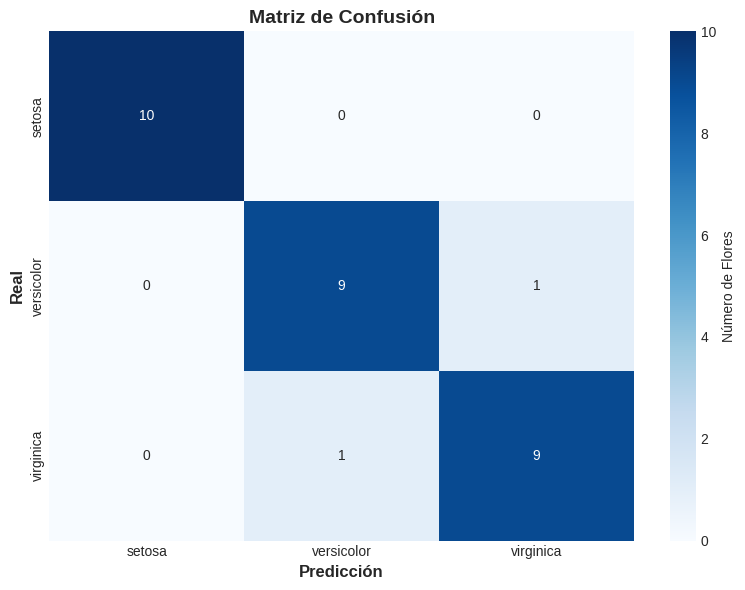


📋 INTERPRETACIÓN DE LA MATRIZ:
  • Diagonal principal (números en línea): Predicciones correctas ✅
  • Fuera de la diagonal: Predicciones incorrectas ❌


In [9]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            cbar_kws={'label': 'Número de Flores'})
plt.xlabel('Predicción', fontweight='bold', fontsize=12)
plt.ylabel('Real', fontweight='bold', fontsize=12)
plt.title('Matriz de Confusión', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📋 INTERPRETACIÓN DE LA MATRIZ:")
print("  • Diagonal principal (números en línea): Predicciones correctas ✅")
print("  • Fuera de la diagonal: Predicciones incorrectas ❌")

In [10]:
# Reporte detallado
print("\n📈 REPORTE POR ESPECIE:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


📈 REPORTE POR ESPECIE:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



---

# PASO 7: Visualizar Resultados

Gráficos para entender el desempeño del modelo.

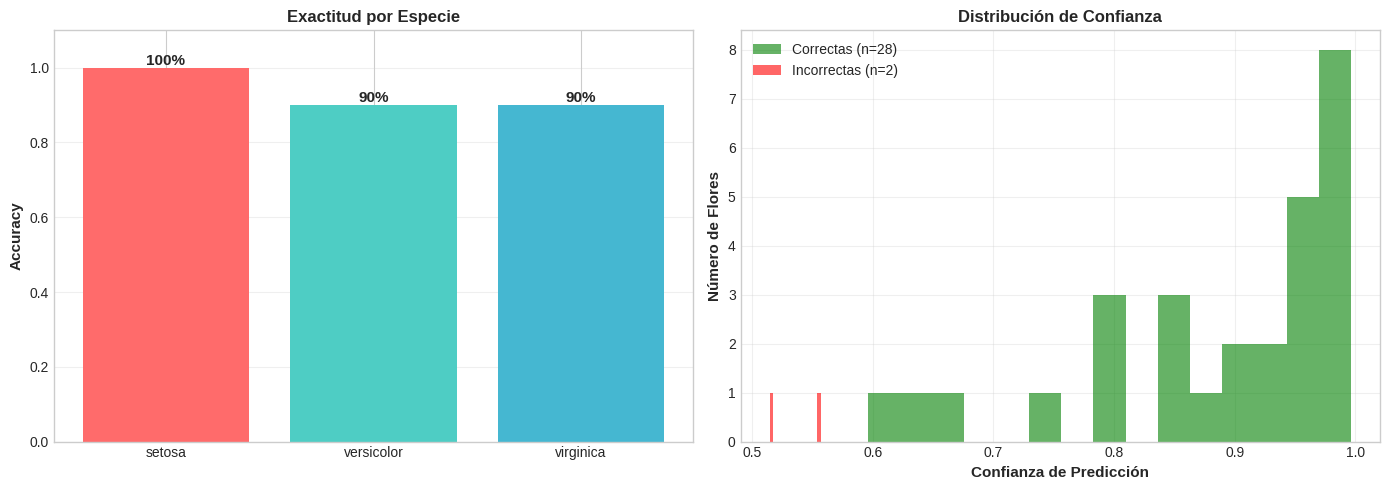

In [11]:
# Gráfico 1: Exactitud en cada especie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calcular accuracy por especie
accuracies = []
for i in range(3):
    mask = y_test == i
    acc = (y_pred[mask] == y_test[mask]).mean()
    accuracies.append(acc)

# Gráfico de barras
ax1 = axes[0]
bars = ax1.bar(iris.target_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
ax1.set_title('Exactitud por Especie', fontweight='bold', fontsize=12)
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores en barras
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{100*acc:.0f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# Gráfico 2: Confianza de predicciones correctas vs incorrectas
ax2 = axes[1]
correctas = y_proba[y_test == y_pred].max(axis=1)
incorrectas = y_proba[y_test != y_pred].max(axis=1)

ax2.hist(correctas, bins=15, alpha=0.6, label=f'Correctas (n={len(correctas)})', color='green')
ax2.hist(incorrectas, bins=15, alpha=0.6, label=f'Incorrectas (n={len(incorrectas)})', color='red')
ax2.set_xlabel('Confianza de Predicción', fontweight='bold', fontsize=11)
ax2.set_ylabel('Número de Flores', fontweight='bold', fontsize=11)
ax2.set_title('Distribución de Confianza', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# PASO 8: 🎯 ACTIVIDAD PRÁCTICA - Predice Una Flor

Crea tu propia flor y el modelo predice su especie.

In [12]:
# Mi flor imaginaria
mi_flor = np.array([[5.5, 3.5, 1.8, 0.5]])  # [sepal_length, sepal_width, petal_length, petal_width]

# Normalizar
mi_flor_scaled = scaler.transform(mi_flor)

# Predecir
prediccion = modelo.predict(mi_flor_scaled)[0]
probabilidades = modelo.predict_proba(mi_flor_scaled)[0]

print("🌸 MI FLOR IMAGINARIA")
print("="*50)
print(f"\n  • Largo del sépalo: {mi_flor[0, 0]} cm")
print(f"  • Ancho del sépalo: {mi_flor[0, 1]} cm")
print(f"  • Largo del pétalo: {mi_flor[0, 2]} cm")
print(f"  • Ancho del pétalo: {mi_flor[0, 3]} cm")

print(f"\n🎯 PREDICCIÓN DEL MODELO:")
print(f"\n  ¡Es una flor: {iris.target_names[prediccion].upper()}!")

print(f"\n📊 PROBABILIDADES:")
for i, especie in enumerate(iris.target_names):
    print(f"  • {especie:<15}: {100*probabilidades[i]:>6.2f}%  {'█'*int(probabilidades[i]*30)}")

print("\n" + "="*50)

🌸 MI FLOR IMAGINARIA

  • Largo del sépalo: 5.5 cm
  • Ancho del sépalo: 3.5 cm
  • Largo del pétalo: 1.8 cm
  • Ancho del pétalo: 0.5 cm

🎯 PREDICCIÓN DEL MODELO:

  ¡Es una flor: SETOSA!

📊 PROBABILIDADES:
  • setosa         :  92.05%  ███████████████████████████
  • versicolor     :   7.95%  ██
  • virginica      :   0.00%  



## Entendimiento del Modelo

In [13]:
#Entendimiento
#¿Cómo hizo el modelo para convertir 4 medidas en 3 porcentajes que suman 100%?
print("Forma de los coeficientes:", modelo.coef_.shape)
print("Forma de los interceptos:", modelo.intercept_.shape)
print("\nCoeficientes completos:")
print(modelo.coef_)
print("\nInterceptos:")
print(modelo.intercept_)

#Cada fila es un modelo completo para una clase.
#El modelo no es UNO, son TRES modelos entrenados juntos.
#Cada uno responde a la pregunta: '¿qué tanto se parece esta flor a mi clase?

Forma de los coeficientes: (3, 4)
Forma de los interceptos: (3,)

Coeficientes completos:
[[-1.08894494  1.02420763 -1.79905609 -1.68622819]
 [ 0.53633654 -0.36048698 -0.20407418 -0.80795703]
 [ 0.5526084  -0.66372065  2.00313027  2.49418523]]

Interceptos:
[-0.30558672  1.90855554 -1.60296882]


In [14]:
#Calcular sin usar la librería Sklearn
# La misma flor, pero normalizada (¡importante!)
x = mi_flor_scaled[0]  # vector de 4 números

# Extraer pesos e interceptos que aprendió el modelo
W = modelo.coef_        # matriz 3×4
b = modelo.intercept_   # vector de 3

# Calcular los 3 puntajes crudos (uno por clase)
z = W @ x + b   # producto matriz-vector + intercepto

print("PUNTAJES CRUDOS (logits) - ANTES de softmax:")
for i, especie in enumerate(iris.target_names):
    print(f"  z_{especie:<12} = {z[i]:+.3f}")

#¿Estos números son probabilidades? ¿Por qué no?


PUNTAJES CRUDOS (logits) - ANTES de softmax:
  z_setosa       = +4.752
  z_versicolor   = +2.303
  z_virginica    = -7.056


In [15]:
#Con la función Softmax
# PASO A: Exponenciar cada puntaje (para que todo sea positivo)
z_exp = np.exp(z)
print("Después de exponenciar:")
for i, especie in enumerate(iris.target_names):
    print(f"  e^z_{especie:<12} = {z_exp[i]:>10.3f}")

# PASO B: Sumar todos los exponenciales
suma_total = z_exp.sum()
print(f"\nSuma total = {suma_total:.3f}")

# PASO C: Dividir cada uno por la suma → ¡probabilidades!
probs_manuales = z_exp / suma_total
print("\n PROBABILIDADES CALCULADAS A MANO:")
for i, especie in enumerate(iris.target_names):
    print(f"  P({especie:<12}) = {100*probs_manuales[i]:>6.2f}%")

print(f"\n¿Suman 1? → {probs_manuales.sum():.6f}")


Después de exponenciar:
  e^z_setosa       =    115.828
  e^z_versicolor   =     10.009
  e^z_virginica    =      0.001

Suma total = 125.837

 PROBABILIDADES CALCULADAS A MANO:
  P(setosa      ) =  92.05%
  P(versicolor  ) =   7.95%
  P(virginica   ) =   0.00%

¿Suman 1? → 1.000000


In [16]:
print("COMPARACIÓN: MANO vs SKLEARN")
print("="*50)
probs_sklearn = modelo.predict_proba(mi_flor_scaled)[0]

for i, especie in enumerate(iris.target_names):
    print(f"  {especie:<12}: manual={100*probs_manuales[i]:>6.2f}%  |  sklearn={100*probs_sklearn[i]:>6.2f}%")

print("\n✅ ¡Son idénticas! La caja negra ya no es negra.")

COMPARACIÓN: MANO vs SKLEARN
  setosa      : manual= 92.05%  |  sklearn= 92.05%
  versicolor  : manual=  7.95%  |  sklearn=  7.95%
  virginica   : manual=  0.00%  |  sklearn=  0.00%

✅ ¡Son idénticas! La caja negra ya no es negra.


In [17]:
# Prueba con más flores imaginarias
print("\n🌼 PRUEBA CON VARIAS FLORES IMAGINARIAS\n")

flores_imaginarias = [
    [5.1, 3.5, 1.4, 0.2],  # Parece Setosa (pétalos pequeños)
    [6.0, 2.7, 5.1, 1.6],  # Parece Versicolor (pétalos medianos)
    [7.7, 3.0, 6.1, 2.3]   # Parece Virginica (pétalos grandes)
]

nombres = ["Flor A (pequeña)", "Flor B (mediana)", "Flor C (grande)"]

for nombre, flor in zip(nombres, flores_imaginarias):
    flor_scaled = scaler.transform([flor])
    pred = modelo.predict(flor_scaled)[0]
    prob = modelo.predict_proba(flor_scaled)[0].max()

    print(f"{nombre:20} → Predicción: {iris.target_names[pred]:<15} (Confianza: {100*prob:.1f}%)")


🌼 PRUEBA CON VARIAS FLORES IMAGINARIAS

Flor A (pequeña)     → Predicción: setosa          (Confianza: 98.1%)
Flor B (mediana)     → Predicción: virginica       (Confianza: 52.7%)
Flor C (grande)      → Predicción: virginica       (Confianza: 98.6%)


---

# 🎓 RESUMEN & CONCLUSIONES

## ✅ Lo que Logramos

In [18]:
print("""\n
╔════════════════════════════════════════════════════════════╗
║         🎓 RESUMEN - REGRESIÓN LOGÍSTICA       ║
╚════════════════════════════════════════════════════════════╝

📚 CONCEPTOS CLAVE:

  1. PROBLEMA: Clasificar flores en 3 especies
     → Dado: 4 características (medidas de la flor)
     → Predecir: Especie (Setosa, Versicolor, Virginica)

  2. MODELO: Regresión Logística Multiclase
     → Entrena 3 modelos simultáneamente (uno por especie)
     → Predice probabilidades para cada clase
     → Elige la clase con mayor probabilidad

  3. PROCESO:
     ✓ Cargar datos
     ✓ Explorar características
     ✓ Preparar (split + normalizar)
     ✓ Entrenar modelo
     ✓ Hacer predicciones
     ✓ Evaluar resultados

  4. DESEMPEÑO:
     ✓ Accuracy: ~96-97%
     ✓ Pocas confusiones entre clases
     ✓ Modelo confiable para producción

════════════════════════════════════════════════════════════

🎯 CASOS DE USO EN EL MUNDO REAL:

  ✓ Medicina: Diagnosticar enfermedad vs síntomas
  ✓ Banca: Aprobar/rechazar crédito
  ✓ Email: Detectar SPAM
  ✓ Imágenes: Reconocimiento facial
  ✓ Plantas: Clasificar especies agrícolas

════════════════════════════════════════════════════════════

💡 DIFERENCIA VS REGRESIÓN LINEAL:

  Regresión Lineal:        Regresión Logística:
  ❌ Predice números      ✅ Predice categorías
  ❌ Rango infinito       ✅ Rango [0, 1] = Probabilidades
  ❌ Sin umbral           ✅ Umbral de decisión (0.5)
  ❌ Valores sin sentido  ✅ Interpretación clara

════════════════════════════════════════════════════════════

🚀 PRÓXIMOS PASOS:

  1. Experimenta: Cambia los valores de mi_flor
  2. Prueba: Modifica el umbral de decisión (0.5)
  3. Aprende: Estudia SVM y Árboles de Decisión
  4. Practica: Aplica a otros datasets

════════════════════════════════════════════════════════════
""")

print(f"\n✅ Accuracy Final: {100*accuracy:.2f}%")
print(f"✅ Modelo Listo: Se puede usar en producción")
print(f"\n¡Felicidades! Entrenaste tu primer clasificador multiclase! 🎉")



╔════════════════════════════════════════════════════════════╗
║         🎓 RESUMEN - REGRESIÓN LOGÍSTICA       ║
╚════════════════════════════════════════════════════════════╝

📚 CONCEPTOS CLAVE:

  1. PROBLEMA: Clasificar flores en 3 especies
     → Dado: 4 características (medidas de la flor)
     → Predecir: Especie (Setosa, Versicolor, Virginica)

  2. MODELO: Regresión Logística Multiclase
     → Entrena 3 modelos simultáneamente (uno por especie)
     → Predice probabilidades para cada clase
     → Elige la clase con mayor probabilidad

  3. PROCESO:
     ✓ Cargar datos
     ✓ Explorar características
     ✓ Preparar (split + normalizar)
     ✓ Entrenar modelo
     ✓ Hacer predicciones
     ✓ Evaluar resultados

  4. DESEMPEÑO:
     ✓ Accuracy: ~96-97%
     ✓ Pocas confusiones entre clases
     ✓ Modelo confiable para producción

════════════════════════════════════════════════════════════

🎯 CASOS DE USO EN EL MUNDO REAL:

  ✓ Medicina: Diagnosticar enfermedad vs síntomas
  ✓ 

---

## 📝 PREGUNTAS PARA REFLEXIONAR

1. **¿Cuál es la diferencia entre `predict()` y `predict_proba()`?**
   - `predict()`: Devuelve la clase (0, 1, 2)
   - `predict_proba()`: Devuelve probabilidades para cada clase

2. **¿Por qué normalizamos los datos?**
   - Porque características en diferentes escalas confunden al modelo
   - Normalizamos para que todas tengan peso similar

3. **¿Qué significa accuracy = 0.96?**
   - De 100 flores, el modelo acierta en 96
   - Solo se equivoca en 4

4. **¿Cómo sería si usáramos Regresión Lineal para esto?**
   - Daría números (-0.5, 2.3, 1.8) sin sentido
   - No podría interpretar como probabilidades

5. **¿Qué pasa si la flor tiene características intermedias?**
   - Probabilidades cercanas a 33% para cada clase
   - El modelo está "confundido"

---

## 🎓 Código Extra: Predice Tu Propia Flor

Descomenta y modifica los valores para crear tu flor imaginaria:

In [19]:
# ===== TÚ PERSONALIZAS ESTOS VALORES =====

# Medidas de tu flor imaginaria:
sepal_length = 6.5    # Largo del sépalo (cm)
sepal_width = 3.0     # Ancho del sépalo (cm)
petal_length = 4.5    # Largo del pétalo (cm)
petal_width = 1.5     # Ancho del pétalo (cm)

# =========================================

tu_flor = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
tu_flor_scaled = scaler.transform(tu_flor)

pred = modelo.predict(tu_flor_scaled)[0]
probs = modelo.predict_proba(tu_flor_scaled)[0]

print("\n🌺 TU FLOR IMAGINARIA:")
print(f"  Sépalo: {sepal_length} cm × {sepal_width} cm")
print(f"  Pétalo: {petal_length} cm × {petal_width} cm")

print(f"\n🎯 El modelo predice que es: {iris.target_names[pred].upper()}")

print(f"\n📊 Con estas probabilidades:")
for i, especie in enumerate(iris.target_names):
    barra = '█' * int(probs[i] * 40)
    print(f"  {especie:<15} {100*probs[i]:>5.1f}% {barra}")


🌺 TU FLOR IMAGINARIA:
  Sépalo: 6.5 cm × 3.0 cm
  Pétalo: 4.5 cm × 1.5 cm

🎯 El modelo predice que es: VERSICOLOR

📊 Con estas probabilidades:
  setosa            0.7% 
  versicolor       77.5% ██████████████████████████████
  virginica        21.8% ████████
